# Probablistic model Eval 1

Here, we establish an evaluation framework to benchmark performance, evaluate future models, and optimize parameters for the probabilistic algorithm. Note that the current Monte Carlo-style simulation is slow; optimizing this execution speed remains an open item.

We initially test against the greedy model, however, it quickly becomes apparent that the benefits of our probablistic model are not seen against a greedy model who does not actively seek to create melds.

In [1]:
import sys, pathlib
# Make the repo root importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agent.eval.harness import run_match, sweep

# Modest numbers to run quickly.
N_GAMES       = 200
KNOCK_SAMPLES = 200
BASE_SEED     = 0

# Coarse pass: cheaper settings + parallel, to locate the promising region fast.
N_GAMES_COARSE       = 30
KNOCK_SAMPLES_COARSE = 64
N_JOBS               = -1     # all cores; set 1 for serial (no joblib needed)

pd.set_option("display.float_format", lambda v: f"{v:.3f}")


# --- tuning helpers ------------------------------------------------------------
N_GAMES_TUNE = 150            # per-cell games for the staged 1-D sweeps below
OPPONENT     = "greedy"       # flip to "meld_seeker" to tune vs the model-matched opponent

from math import erfc, sqrt as _sqrt
def add_significance(df, n_games, baseline=0.5):
    """Add win-rate SE and a z-test of win_rate vs `baseline` (0.5 = even with
    the opponent). Each game is ~Bernoulli, so SE = sqrt(p(1-p)/n); p_value is the
    two-sided normal tail. Check this before reading into a cell's ranking."""
    out = df.copy()
    p = out["win_rate"].to_numpy()
    se = np.sqrt(p * (1 - p) / n_games)
    z = np.divide(p - baseline, se, out=np.zeros_like(p), where=se > 0)
    out["se"] = se
    out["z_vs_0.5"] = z
    out["p_value"] = [erfc(abs(zi) / _sqrt(2)) for zi in z]
    return out

def heatmap(df, x, y, metric, ax=None, title=None):
    """Pivot a sweep DataFrame to a grid and render metric as a heatmap."""
    grid = df.pivot_table(index=y, columns=x, values=metric)
    ax = ax or plt.gca()
    im = ax.imshow(grid.values, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(grid.columns))); ax.set_xticklabels(grid.columns)
    ax.set_yticks(range(len(grid.index)));   ax.set_yticklabels(grid.index)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title or metric)
    for (i, j), v in np.ndenumerate(grid.values):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="w", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return grid

## Probablistic ties greedy.

Against the greedy baseline the Bayesian agent lands basically at parity. The plot below shows the win rate with a 1-SE bar
against the 0.5 line and the p-value.

On reflection, this is sensible as the bayesian layer is callibrated for a player seeking to collect certain cards, where as the greedy algorithm just discards to minimise deadwood and as such gives our model false signals - reducing it in itself to close to the greedy algorithm.

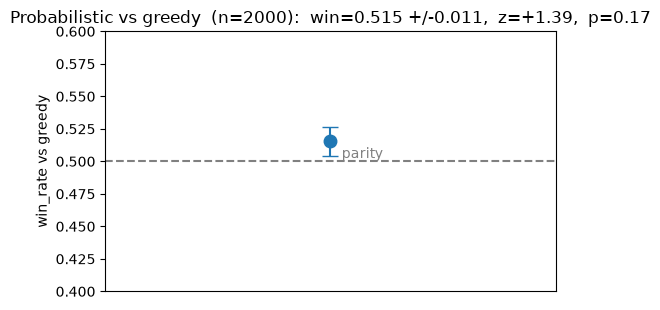

avg_score_margin=+0.87  knock_rate=0.51  gin_rate=0.01


In [ ]:
HEAD2HEAD_N = 200
res = run_match(("probabilistic", {"alpha": 0.3, "gamma": 0.0, "kappa": 0.0,
                                    "knock_samples": KNOCK_SAMPLES}),
                ("greedy", {}), n_games=HEAD2HEAD_N, base_seed=BASE_SEED,
                alternate_seats=True)
p = res["win_rate"]; se = (p * (1 - p) / HEAD2HEAD_N) ** 0.5
z = (p - 0.5) / se; pval = erfc(abs(z) / _sqrt(2))
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.errorbar([0], [p], yerr=[se], fmt="o", ms=9, capsize=6)
ax.axhline(0.5, ls="--", color="grey")
ax.set_xlim(-1, 1); ax.set_xticks([]); ax.set_ylim(0.40, 0.60)
ax.set_ylabel("win_rate vs greedy")
ax.set_title(f"Probabilistic vs greedy  (n={HEAD2HEAD_N}):  "
             f"win={p:.3f} +/-{se:.3f},  z={z:+.2f},  p={pval:.2f}")
ax.text(0.05, 0.5, "parity", color="grey", va="bottom")
plt.tight_layout(); plt.show()
print(f"avg_score_margin={res['avg_score_margin']:+.2f}  "
      f"knock_rate={res['knock_rate']:.2f}  gin_rate={res['gin_rate']:.2f}")

## The policy knobs are neutral (alpha, kappa)

Neither lever moves the result against greedy. `alpha` (discard risk weight)
changes how the agent plays -- own deadwood rises with it -- but is win-rate
neutral. `kappa` (knock opportunity cost) is inert until ~25, where making the
agent knock more selectively actively *hurts*: greedy knocks the moment it is
legal and out-races a hesitant knocker. Both stages below run n=150/cell with SE
and p-value columns; the error bars straddle 0.5 throughout.

In [ ]:
# At n=150 the win-rate SE is ~0.04, so cell-to-cell gaps
# below ~0.08 are not meaningful.
alpha_stage = sweep(
    {"alpha": [0.0, 0.1, 0.2, 0.3, 0.4]},
    opponent=(OPPONENT, {}),
    fixed={"gamma": 0.0, "kappa": 0.0, "knock_samples": KNOCK_SAMPLES},
    n_games=N_GAMES_TUNE, base_seed=BASE_SEED, alternate_seats=True, n_jobs=N_JOBS,
)
df_alpha = add_significance(pd.DataFrame(alpha_stage), N_GAMES_TUNE)
BEST_ALPHA = float(df_alpha.loc[df_alpha["win_rate"].idxmax(), "alpha"])
print(f"alpha held for stage 2 = {BEST_ALPHA}  "
      f"(highest win_rate -- but check p_value; likely not significant vs 0.5)")
df_alpha.sort_values("win_rate", ascending=False)[
    ["alpha", "win_rate", "se", "z_vs_0.5", "p_value",
     "avg_score_margin", "avg_deadwood", "knock_rate"]]

alpha held for stage 2 = 0.3  (highest win_rate -- but check p_value; likely not significant vs 0.5)


,alpha,win_rate,se,z_vs_0.5,p_value,avg_score_margin,avg_deadwood,knock_rate
3,0.300,0.513,0.041,0.327,0.744,-0.087,13.680,0.527
2,0.200,0.507,0.041,0.163,0.870,-0.073,14.180,0.513
1,0.100,0.500,0.041,0.000,1.000,-0.227,14.027,0.507
4,0.400,0.500,0.041,0.000,1.000,-0.060,13.893,0.500
0,0.000,0.493,0.041,-0.163,0.870,-0.987,14.893,0.513


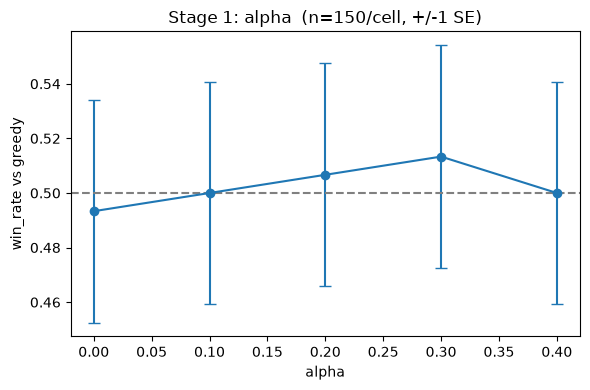

In [4]:
# Stage 1 read: win_rate vs alpha with +/-1 SE bars; dashed line = parity (0.5).
# If the band straddles 0.5 across the row, alpha isn't separating from greedy.
d = df_alpha.sort_values("alpha")
plt.figure(figsize=(6, 4))
plt.errorbar(d["alpha"], d["win_rate"], yerr=d["se"], marker="o", capsize=4)
plt.axhline(0.5, ls="--", color="grey")
plt.xlabel("alpha"); plt.ylabel(f"win_rate vs {OPPONENT}")
plt.title(f"Stage 1: alpha vs {OPPONENT}  (n={N_GAMES_TUNE}/cell, +/-1 SE)")
plt.tight_layout(); plt.show()

In [ ]:
# THE money plot: alpha vs both caricatures on one axis. Flat on 0.5 against
# greedy (belief-illegible) vs a significant arch above 0.5 against the
# meld-seeker (model-matched) -- alpha's value is opponent-dependent.
fig, ax = plt.subplots(figsize=(7, 4.5))
for opp, color in [("greedy", "tab:blue"), ("meld_seeker", "tab:orange")]:
    g = sweep({"alpha": [0.0, 0.1, 0.2, 0.3, 0.4]},
              opponent=(opp, {}),
              fixed={"gamma": 0.0, "kappa": 0.0, "knock_samples": KNOCK_SAMPLES},
              n_games=N_GAMES_TUNE, base_seed=BASE_SEED, alternate_seats=True, n_jobs=N_JOBS)
    d = add_significance(pd.DataFrame(g), N_GAMES_TUNE).sort_values("alpha")
    ax.errorbar(d["alpha"], d["win_rate"], yerr=d["se"], marker="o", capsize=4,
                color=color, label=f"vs {opp}")
ax.axhline(0.5, ls="--", color="grey")
ax.set_xlabel("alpha"); ax.set_ylabel("win_rate (+/-1 SE)")
ax.set_title(f"Alpha is opponent-dependent  (n={N_GAMES_TUNE}/cell)")
ax.legend(); plt.tight_layout(); plt.show()

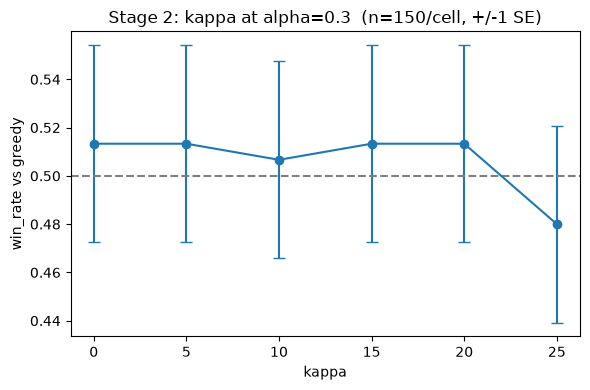

,kappa,win_rate,se,z_vs_0.5,p_value,gin_rate,undercut_against_rate,knock_rate
0,0.000,0.513,0.041,0.327,0.744,0.013,0.033,0.527
1,5.000,0.513,0.041,0.327,0.744,0.013,0.033,0.527
3,15.000,0.513,0.041,0.327,0.744,0.013,0.027,0.507
4,20.000,0.513,0.041,0.327,0.744,0.013,0.027,0.493
2,10.000,0.507,0.041,0.163,0.870,0.013,0.033,0.520
5,25.000,0.480,0.041,-0.490,0.624,0.013,0.027,0.427


In [ ]:
# Kappa at the stage-1 alpha.
kappa_stage = sweep(
    {"kappa": [0.0, 5.0, 10.0, 15.0, 20.0, 25.0]},
    opponent=(OPPONENT, {}),
    fixed={"gamma": 0.0, "alpha": BEST_ALPHA, "knock_samples": KNOCK_SAMPLES},
    n_games=N_GAMES_TUNE, base_seed=BASE_SEED, alternate_seats=True, n_jobs=N_JOBS,
)
df_kappa = add_significance(pd.DataFrame(kappa_stage), N_GAMES_TUNE)
d = df_kappa.sort_values("kappa")
plt.figure(figsize=(6, 4))
plt.errorbar(d["kappa"], d["win_rate"], yerr=d["se"], marker="o", capsize=4)
plt.axhline(0.5, ls="--", color="grey")
plt.xlabel("kappa"); plt.ylabel(f"win_rate vs {OPPONENT}")
plt.title(f"Stage 2: kappa at alpha={BEST_ALPHA} vs {OPPONENT}  (n={N_GAMES_TUNE}/cell)")
plt.tight_layout(); plt.show()
df_kappa.sort_values("win_rate", ascending=False)[
    ["kappa", "win_rate", "se", "z_vs_0.5", "p_value",
     "gin_rate", "undercut_against_rate", "knock_rate"]]

## The right benchmark

As our model gains no real benefit against a greedy model, it functions as a lower bound.
An sensible upper bound to win rate would be an opponent that fits the generative model:
`MeldSeekerPolicy` (agent/eval/opponents.py) holds meld-potential cards and
discards the most isolated one, telegraphing what it collects.

Two views below: win rate vs each caricature, and a direct
calibration curve of how much probability the belief puts on
the opponent's actual cards over a game. 

Neither of these models function like a rational agent, who would mix both ideologies,
but it gives us an idea of a sensible range for our parametres.

prob vs greedy       win=0.500  margin=-0.23
prob vs meld_seeker  win=0.640  margin=+7.36


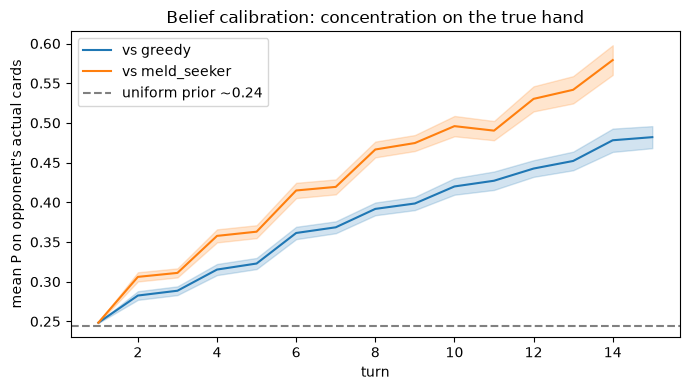

In [ ]:
from agent.eval.calibration import calibration_curve

for opp in ("greedy", "meld_seeker"):
    r = run_match(("probabilistic", {"alpha": 0.1, "kappa": 0.0,
                                     "knock_samples": KNOCK_SAMPLES}),
                  (opp, {}), n_games=N_GAMES_TUNE, base_seed=BASE_SEED,
                  alternate_seats=True)
    print(f"prob vs {opp:12} win={r['win_rate']:.3f}  margin={r['avg_score_margin']:+.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
for kind, color in [("greedy", "tab:blue"), ("meld_seeker", "tab:orange")]:
    t, m, se, prior = calibration_curve(kind, n_games=40)
    ax.plot(t, m, color=color, label=f"vs {kind}")
    ax.fill_between(t, m - se, m + se, color=color, alpha=0.2)
ax.axhline(prior, ls="--", color="grey", label=f"uniform prior ~{prior:.2f}")
ax.set_xlabel("turn"); ax.set_ylabel("mean P on opponent's actual cards")
ax.set_title("Belief calibration: concentration on the true hand")
ax.legend(); plt.tight_layout(); plt.show()

## Testing against the Meld Seeker:

We run the same test as against greedy to get our upper bound for alpha. It appears a low moderate value is best against an opponent who builds melds. However, kappa remains inert to negative for high values.

In [17]:
alpha_stage = sweep(
    {"alpha": [0.0, 0.1, 0.2, 0.3, 0.4]},
    fixed={"gamma": 0.0, "kappa": 0.0, "knock_samples": KNOCK_SAMPLES},
    n_games=N_GAMES_TUNE, base_seed=BASE_SEED, alternate_seats=True, n_jobs=N_JOBS,opponent=("meld_seeker",{})
)
df_alpha = add_significance(pd.DataFrame(alpha_stage), N_GAMES_TUNE)
BEST_ALPHA = float(df_alpha.loc[df_alpha["win_rate"].idxmax(), "alpha"])
df_alpha.sort_values("win_rate", ascending=False)[
    ["alpha", "win_rate", "se", "z_vs_0.5", "p_value",
     "avg_score_margin", "avg_deadwood", "knock_rate"]]

,alpha,win_rate,se,z_vs_0.5,p_value,avg_score_margin,avg_deadwood,knock_rate
1,0.100,0.640,0.039,3.572,0.000,7.360,12.447,0.627
2,0.200,0.613,0.040,2.850,0.004,6.827,12.420,0.580
0,0.000,0.593,0.040,2.327,0.020,6.527,13.113,0.573
3,0.300,0.593,0.040,2.327,0.020,6.527,12.473,0.587
4,0.400,0.567,0.040,1.648,0.099,5.927,12.753,0.567


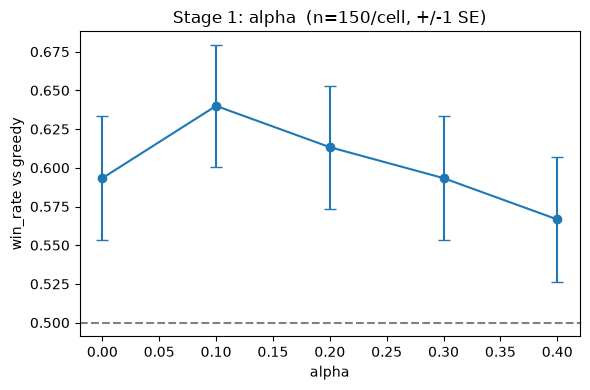

In [ ]:
d = df_alpha.sort_values("alpha")
plt.figure(figsize=(6, 4))
plt.errorbar(d["alpha"], d["win_rate"], yerr=d["se"], marker="o", capsize=4)
plt.axhline(0.5, ls="--", color="grey")
plt.xlabel("alpha"); plt.ylabel("win_rate vs meld seeker")
plt.title(f"Stage 1: alpha  (n={N_GAMES_TUNE}/cell, +/-1 SE)")
plt.tight_layout(); plt.show()

In [21]:
OPPONENT = "meld_seeker"
kappa_stage = sweep(
    {"kappa": [0.0, 5.0, 10.0, 15.0, 20.0, 25.0]},
    opponent=(OPPONENT,{}),
    fixed={"gamma": 0.0, "alpha": BEST_ALPHA, "knock_samples": KNOCK_SAMPLES},
    n_games=N_GAMES_TUNE, base_seed=BASE_SEED, alternate_seats=True, n_jobs=N_JOBS,
)
df_kappa = add_significance(pd.DataFrame(kappa_stage), N_GAMES_TUNE)
d = df_kappa.sort_values("kappa")
plt.figure(figsize=(6, 4))
plt.errorbar(d["kappa"], d["win_rate"], yerr=d["se"], marker="o", capsize=4)
plt.axhline(0.5, ls="--", color="grey")
plt.xlabel("kappa"); plt.ylabel(f"win_rate vs {OPPONENT}")
plt.title(f"Stage 2: kappa at alpha={BEST_ALPHA} vs {OPPONENT}  (n={N_GAMES_TUNE}/cell)")
plt.tight_layout(); plt.show()
df_kappa.sort_values("win_rate", ascending=False)[
    ["kappa", "win_rate", "se", "z_vs_0.5", "p_value",
     "gin_rate", "undercut_against_rate", "knock_rate"]]

KeyboardInterrupt: 

## Belief testing on meld_seeker

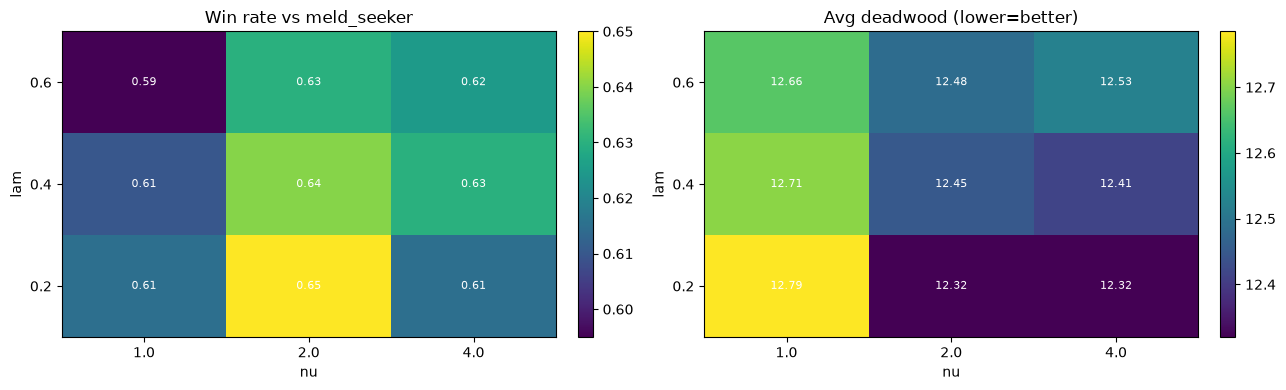

,mu,alpha,kappa,knock_samples,nu,lam,n_games,win_rate,loss_rate,draw_rate,timeout_rate,avg_deadwood,avg_score_margin,knock_rate,gin_rate,undercut_against_rate,undercut_by_rate,avg_turns
0,0.400,0.100,0.000,200,1.000,0.200,200,0.615,0.385,0.000,0.000,12.785,8.565,0.605,0.020,0.000,0.010,11.355
1,0.400,0.100,0.000,200,1.000,0.400,200,0.610,0.390,0.000,0.000,12.705,8.630,0.600,0.015,0.000,0.010,11.390
2,0.400,0.100,0.000,200,1.000,0.600,200,0.595,0.405,0.000,0.000,12.665,8.130,0.595,0.015,0.000,0.000,11.485
3,0.400,0.100,0.000,200,2.000,0.200,200,0.650,0.350,0.000,0.000,12.320,9.385,0.650,0.020,0.000,0.000,11.820
4,0.400,0.100,0.000,200,2.000,0.400,200,0.640,0.360,0.000,0.000,12.450,9.405,0.635,0.020,0.000,0.005,11.695
5,0.400,0.100,0.000,200,2.000,0.600,200,0.630,0.370,0.000,0.000,12.485,8.940,0.625,0.020,0.000,0.005,11.755
6,0.400,0.100,0.000,200,4.000,0.200,200,0.615,0.385,0.000,0.000,12.320,9.235,0.600,0.020,0.000,0.015,12.040
7,0.400,0.100,0.000,200,4.000,0.400,200,0.630,0.370,0.000,0.000,12.415,10.105,0.615,0.025,0.000,0.015,12.045
8,0.400,0.100,0.000,200,4.000,0.600,200,0.625,0.375,0.000,0.000,12.525,9.040,0.615,0.025,0.000,0.010,12.175


In [22]:
belief_grid = sweep(
    {"nu": [1.0, 2.0, 4.0],
     "lam": [0.2, 0.4, 0.6]},
    fixed={"mu": 0.4, "alpha": 0.1, "kappa": 0.0,
           "knock_samples": KNOCK_SAMPLES},
    n_games=N_GAMES, base_seed=BASE_SEED,
    opponent=(OPPONENT,{})
)
df_belief = pd.DataFrame(belief_grid)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
heatmap(df_belief, x="nu", y="lam", metric="win_rate",
        ax=axes[0], title="Win rate vs "+OPPONENT)
heatmap(df_belief, x="nu", y="lam", metric="avg_deadwood",
        ax=axes[1], title="Avg deadwood (lower=better)")
plt.tight_layout(); plt.show()
df_belief

## Conclusions & next steps

From this first evaluation, we choose: alpha=0.1, kappa=0.0, gamma=0.0, mu=0.4, nu=2.0, lam=0.4. 

The belief-knob grid vs meld_seeker confirms the defaults — nu=2.0 leads on win rate (~0.64) and deadwood, lam is flat, everything sits within ~1 SE.

Against greedy the agent only ties (win 0.515, p=0.17) as greedy is strong on fundamentals and belief-illegible. 

The belief itself is fine — calibration climbs from the 0.24 prior and the agent beats meld-builders 0.59–0.65 — so the ceiling is the myopic one-ply policy, not the inference.

We will build a rational bot: greedy and meld_seeker are caricatures (lower and upper bounds); no real agent is purely one, and you can't pick parameters or judge a policy against a caricature without overfitting to it. rational is a blend (potentially a random one) of deadwood management and meld-building into a more realistic benchmark.

Next: test gamma properly. It prices the info-leak of taking a card face-up, which only a belief-using opponent punishes — none of greedy/meld/rational model us, so it's untestable against them. It must be run in prob-vs-prob self-play.